In [1]:
import os
import pandas as pd

In [ ]:
#pip install scrapy

In [ ]:
#pip install tqdm

In [2]:
from scrapy import Selector
from tqdm.notebook import trange

## 1. Data Input

In [6]:
DATA_FOLDER = '../Data/Profile'

html_files = [os.path.join(DATA_FOLDER, file)
               for file in os.listdir(DATA_FOLDER)
                 if file.endswith('.html')]

In [7]:
html_files

['../Data/Profile\\index (1).html',
 '../Data/Profile\\index (10).html',
 '../Data/Profile\\index (11).html',
 '../Data/Profile\\index (12).html',
 '../Data/Profile\\index (13).html',
 '../Data/Profile\\index (14).html',
 '../Data/Profile\\index (15).html',
 '../Data/Profile\\index (16).html',
 '../Data/Profile\\index (17).html',
 '../Data/Profile\\index (21).html',
 '../Data/Profile\\index (31).html',
 '../Data/Profile\\index (32).html',
 '../Data/Profile\\index (33).html',
 '../Data/Profile\\index (35).html',
 '../Data/Profile\\index (36).html',
 '../Data/Profile\\index (4).html',
 '../Data/Profile\\index (5).html',
 '../Data/Profile\\Index (6).html',
 '../Data/Profile\\index (8).html',
 '../Data/Profile\\index (9).html']

In [8]:
files_content = []
for file in html_files:
    with open(file, 'r', encoding='utf-8') as f:
        files_content.append(f.read())

len(files_content)

20

In [9]:
files_content[0]

'<!DOCTYPE html>\n<html>\n\n<head>\n    <title>MY MINI CV</title>\n    <style type="text/css">\n    body {\n        font-family: \'Lucida Sans\', \'Lucida Sans Regular\', \'Lucida Grande\', \'Lucida Sans Unicode\', Geneva, Verdana, sans-serif;\n        padding: 1em;\n    }\n\n    h1 {\n        color: #333;\n        font-family: \'Segoe UI\', Tahoma, Geneva, Verdana, sans-serif;\n    }\n\n    h2 {\n        color: #333;\n    }\n\n    h3 {\n        color: #333;\n    }\n\n    .title {\n        color: #333;\n    }\n\n    .subtitle {\n        color: #333;\n    }\n\n    .content {\n        color: #333;\n    }\n\n    ul {\n        list-style-type: none;\n        padding: 0;\n    }\n\n    li {\n        background-color: #f9f9f9;\n        padding: 1em;\n        margin: 0.5em;\n        border-radius: 5px;\n        display: inline-block;\n    }\n\n    a {\n        color: #333;\n        text-decoration: none;\n    }\n\n    a:hover {\n        color: #666;\n    }\n\n    img {\n        vertical-align:

## Demo of Selector() class

In [10]:
html_files = files_content[0]
sel = Selector(text=html_files)

#### To search for a single tag

In [11]:
sel.css('h1')

[<Selector query='descendant-or-self::h1' data='<h1>POOJASRI S</h1>'>]

In [12]:
sel.css('h1::text').get()

'POOJASRI S'

In [13]:
sel.css('h1::text').getall()

['POOJASRI S']

#### To search and get multiple elements at once use the getall() method

In [14]:
sel.css('ul li').getall()

['<li>Python</li>',
 '<li>Machine learning</li>',
 '<li>RDBMS</li>',
 '<li>Power BI</li>',
 '<li><img src="https://img.icons8.com/ios/50/000000/github.png" style="height:1.1em;vertical-align:middle"> GitHub username: <a href="https://github.com/poojaa-sri">@pooja</a></li>',
 '<li><img src="https://img.icons8.com/ios/50/000000/slack.png" style="height:1.1em;vertical-align:middle"> LinkedIn Profile: <a href="https://www.linkedin.com/in/poojasri-saravanakumar/recent-activity/all/">@pooja</a></li>']

In [15]:
sel.css('ul li::text').getall()

['Python',
 'Machine learning',
 'RDBMS',
 'Power BI',
 ' GitHub username: ',
 ' LinkedIn Profile: ']

#### Be more specific with your CSS Selector to avoid scraping unwanted data

In [16]:
sel.css('#bio ul li::text').getall()

['Python', 'Machine learning', 'RDBMS', 'Power BI']

# Looping over all pages

In [17]:
ids = []
data_science_skills = []
sname = []

for id in range(len(files_content)):
    ids.append(id)

    #Collect the skills listed on the website
    html_text = files_content[id]
    sel = Selector(text=html_text)
    snames = sel.css('h1::text').getall()
    sname.append(snames)
    skills = sel.css('#bio ul li::text').getall()
    data_science_skills.append(skills)

In [18]:
df = pd.DataFrame({
    'ID': ids,
    'Student_Name': sname,
    'skills': data_science_skills,})
df

,ID,Student_Name,skills
0,0,[POOJASRI S],"[Python, Machine learning, RDBMS, Power BI]"
1,1,[ANDRO PRAVEEN K],"[EXCEL, PYTHON, SQL, DATA ENGINEERING]"
2,2,[Ajay],"[Excel, SQL, Python, Big Data Analytics]"
3,3,[NISHA],"[Python, Data Engineering, Rdbms, Java]"
4,4,[HARDIKA S],"[PYTHON, RDBMS, POWER BI, HTML]"
5,5,[M.AISHWARYA],"[Python , Java , SQL , Data Engneering ]"
6,6,[MAHALAKSHMI],"[Python, Data Engineering using pyhton, HTML, ..."
7,7,[SHALINI],"[Python, Data Science, HTML, Linux]"
8,8,[Naveen sakthi],"[Python , MYSQL, Power BI , Machine Learning ,..."
9,9,[SANMUGAPRIYA],"[Python, Data Engineering, Rdbms, Excel]"


In [19]:
df.explode('skills')

,ID,Student_Name,skills
0,0,[POOJASRI S],Python
0,0,[POOJASRI S],Machine learning
0,0,[POOJASRI S],RDBMS
0,0,[POOJASRI S],Power BI
1,1,[ANDRO PRAVEEN K],EXCEL
...,...,...,...
18,18,[Sudha],Power Bi
19,19,[Devadharshni_Sownderrajan],Python
19,19,[Devadharshni_Sownderrajan],SQL
19,19,[Devadharshni_Sownderrajan],Excel


In [20]:
df.explode('skills')['skills'].value_counts()   

skills
Python                           11
RDBMS                             6
SQL                               6
PYTHON                            5
Excel                             5
Java                              5
HTML                              4
Data Engineering                  4
Python                            3
Power BI                          3
Machine learning                  2
DATA ENGINEERING                  2
Data Engneering                   2
Rdbms                             2
EXCEL                             2
SQL                               2
Machine Learning                  2
Html                              2
Big Data Analytics                1
POWER BI                          1
Data Engineering using pyhton     1
Java                              1
MYSQL                             1
Data Science                      1
Power BI                          1
Machine Learning                  1
Web scraping                      1
Linux                

In [21]:
df.explode('skills')

,ID,Student_Name,skills
0,0,[POOJASRI S],Python
0,0,[POOJASRI S],Machine learning
0,0,[POOJASRI S],RDBMS
0,0,[POOJASRI S],Power BI
1,1,[ANDRO PRAVEEN K],EXCEL
...,...,...,...
18,18,[Sudha],Power Bi
19,19,[Devadharshni_Sownderrajan],Python
19,19,[Devadharshni_Sownderrajan],SQL
19,19,[Devadharshni_Sownderrajan],Excel


In [22]:
df.explode('skills')[df.explode('skills')['skills'] == 'Python']

,ID,Student_Name,skills
0,0,[POOJASRI S],Python
2,2,[Ajay],Python
3,3,[NISHA],Python
6,6,[MAHALAKSHMI],Python
7,7,[SHALINI],Python
9,9,[SANMUGAPRIYA],Python
13,13,[Sriswathika Selvaraj],Python
14,14,[GOWTHAMRAJ.K],Python
15,15,[AKSHAYAKEERTHIYA M],Python
17,17,[ASIF FARWAYS JAHANGIR],Python


In [23]:
df.explode('skills')[df.explode('skills')['skills'] == 'Data Engineering']

,ID,Student_Name,skills
3,3,[NISHA],Data Engineering
9,9,[SANMUGAPRIYA],Data Engineering
15,15,[AKSHAYAKEERTHIYA M],Data Engineering
17,17,[ASIF FARWAYS JAHANGIR],Data Engineering


In [24]:
df_exploded = df.explode('skills')

In [25]:
df_exploded

,ID,Student_Name,skills
0,0,[POOJASRI S],Python
0,0,[POOJASRI S],Machine learning
0,0,[POOJASRI S],RDBMS
0,0,[POOJASRI S],Power BI
1,1,[ANDRO PRAVEEN K],EXCEL
...,...,...,...
18,18,[Sudha],Power Bi
19,19,[Devadharshni_Sownderrajan],Python
19,19,[Devadharshni_Sownderrajan],SQL
19,19,[Devadharshni_Sownderrajan],Excel


In [26]:
df_exploded['skills'] = df_exploded['skills'].str.strip().str.upper()

In [27]:
df_exploded

,ID,Student_Name,skills
0,0,[POOJASRI S],PYTHON
0,0,[POOJASRI S],MACHINE LEARNING
0,0,[POOJASRI S],RDBMS
0,0,[POOJASRI S],POWER BI
1,1,[ANDRO PRAVEEN K],EXCEL
...,...,...,...
18,18,[Sudha],POWER BI
19,19,[Devadharshni_Sownderrajan],PYTHON
19,19,[Devadharshni_Sownderrajan],SQL
19,19,[Devadharshni_Sownderrajan],EXCEL


In [28]:
skill_counts = df_exploded['skills'].value_counts()
print(skill_counts)

skills
PYTHON                           19
SQL                              10
EXCEL                             8
RDBMS                             8
JAVA                              7
DATA ENGINEERING                  7
HTML                              6
POWER BI                          6
MACHINE LEARNING                  5
DATA ENGNEERING                   2
BIG DATA ANALYTICS                1
DATA ENGINEERING USING PYHTON     1
DATA SCIENCE                      1
LINUX                             1
MYSQL                             1
WEB SCRAPING                      1
CSS                               1
                                  1
Name: count, dtype: int64


In [29]:
skill_counts = df_exploded.groupby('skills').size().reset_index(name='count')
print(skill_counts)

                           skills  count
0                                      1
1              BIG DATA ANALYTICS      1
2                             CSS      1
3                DATA ENGINEERING      7
4   DATA ENGINEERING USING PYHTON      1
5                 DATA ENGNEERING      2
6                    DATA SCIENCE      1
7                           EXCEL      8
8                            HTML      6
9                            JAVA      7
10                          LINUX      1
11               MACHINE LEARNING      5
12                          MYSQL      1
13                       POWER BI      6
14                         PYTHON     19
15                          RDBMS      8
16                            SQL     10
17                   WEB SCRAPING      1


In [30]:
skill_count_df = skill_counts.reset_index()
skill_count_df.columns = ['ID', 'Skill', 'Frequency']
print(skill_count_df)

    ID                          Skill  Frequency
0    0                                         1
1    1             BIG DATA ANALYTICS          1
2    2                            CSS          1
3    3               DATA ENGINEERING          7
4    4  DATA ENGINEERING USING PYHTON          1
5    5                DATA ENGNEERING          2
6    6                   DATA SCIENCE          1
7    7                          EXCEL          8
8    8                           HTML          6
9    9                           JAVA          7
10  10                          LINUX          1
11  11               MACHINE LEARNING          5
12  12                          MYSQL          1
13  13                       POWER BI          6
14  14                         PYTHON         19
15  15                          RDBMS          8
16  16                            SQL         10
17  17                   WEB SCRAPING          1


In [31]:
import matplotlib.pyplot as plt

<Axes: title={'center': 'Skill Frequency'}, xlabel='Skill'>

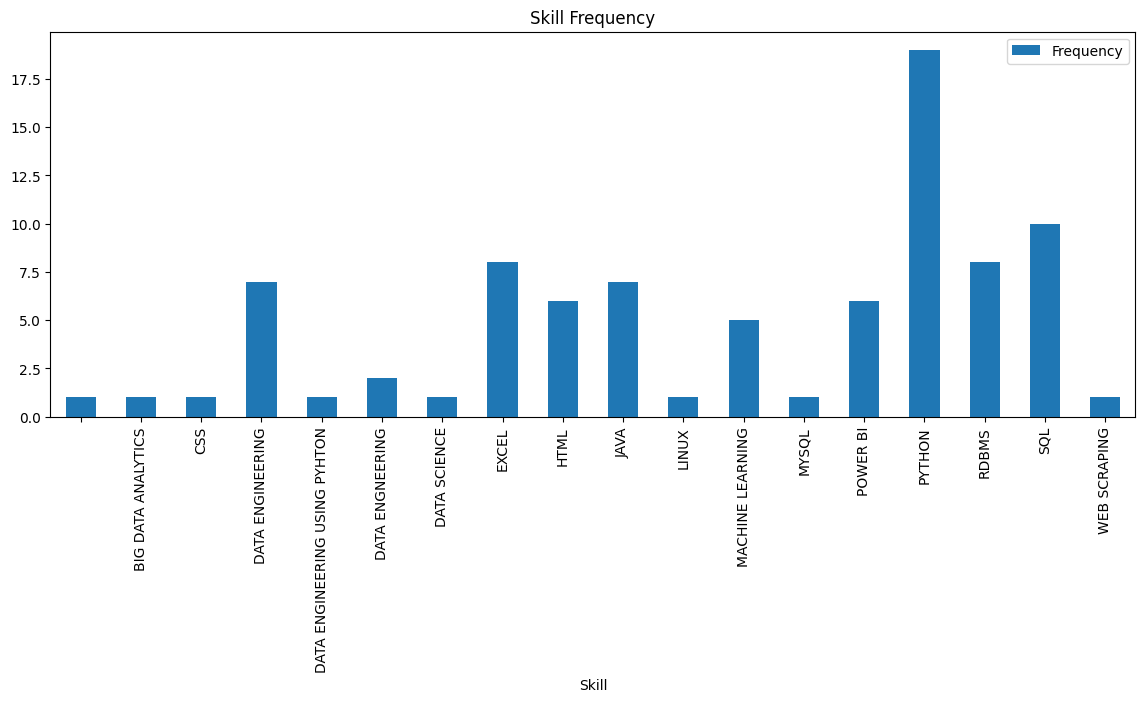

In [32]:
skill_count_df.plot(kind='bar', x='Skill', y='Frequency', title='Skill Frequency', figsize=(14, 5))

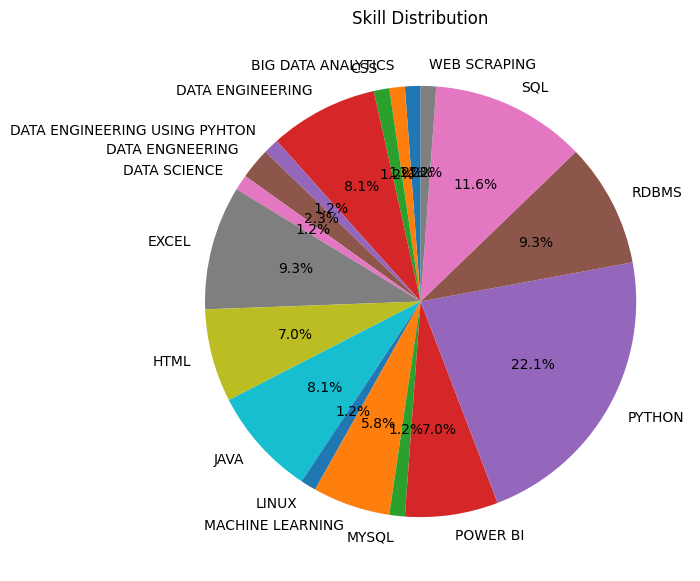

In [33]:
plt.figure(figsize = (7, 7))
plt.pie(skill_count_df['Frequency'], labels=skill_count_df['Skill'], 
        autopct='%1.1f%%', 
        startangle=90
        )
plt.title('Skill Distribution')
plt.show()